# Variance Comparison Across ResShift Models

Compare forward transition variance and posterior variance for `v1`, `v2`, and `v3`, and overlay their ratio curves.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf

from utils.util_common import instantiate_from_config

In [ ]:
IMAGE_DIR = Path(r"/Users/alan/ResShift/testdata/Bicubicx4/lq_matlab")
IMAGE_NAME = "ILSVRC2012_val_00000079.png"
IN_PATH = IMAGE_DIR / IMAGE_NAME

MODEL_CONFIGS = {
    "v1": "./configs/realsr_swinunet_realesrgan256.yaml",
}

In [ ]:
def load_diffusion(config_path):
    configs = OmegaConf.load(config_path)
    return instantiate_from_config(configs.diffusion)

def compute_variances(diffusion):
    timesteps = np.arange(diffusion.num_timesteps)
    

    forward_var = diffusion.alpha * (diffusion.kappa ** 2)  
    
    posterior_var = diffusion.posterior_variance_clipped    
    
 
    ratio_forward_over_posterior = forward_var /posterior_var

    ratio_posterior_over_forward = posterior_var/forward_var

    return timesteps, forward_var, posterior_var, ratio_forward_over_posterior, ratio_posterior_over_forward

def plot_variance_curves(ax, timesteps, forward_var, posterior_var, title):
    ax.plot(timesteps[1:], forward_var[1:], marker='o', label='Forward variance')
    ax.plot(timesteps[1:], posterior_var[1:], marker='o', label='Posterior variance')
    
    ax.set_yscale('log')
    ax.set_title(title)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Variance (log scale)')
    ax.grid(False)
    ax.legend()

def plot_ratio_overlay(results, ratio_type='forward_over_posterior'):
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    
    if ratio_type == 'forward_over_posterior':
        ratio_index = 3
        title = 'Variance Ratio Comparison (Forward / Posterior)'
        format_str = '{:.2f}'
    else:  # posterior_over_forward
        ratio_index = 4
        title = 'Variance Ratio Comparison (Posterior / Forward)'
        format_str = '{:.2f}'
    
    for name, data in results.items():
        timesteps = data[0]
        ratio = data[ratio_index]

        timesteps_plot = timesteps[1:]
        ratio_plot = ratio[1:]

        ax.plot(timesteps_plot, ratio_plot, marker='o', label=name)

        for t, r in zip(timesteps_plot, ratio_plot):
            ax.annotate(format_str.format(r), xy=(t, r), xytext=(0, 10),
                        textcoords='offset points',
                        ha='center', va='bottom', fontsize=12)
    
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Ratio')
    ax.set_title(title)
    ax.grid(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

No module 'xformers'. Proceeding without it.


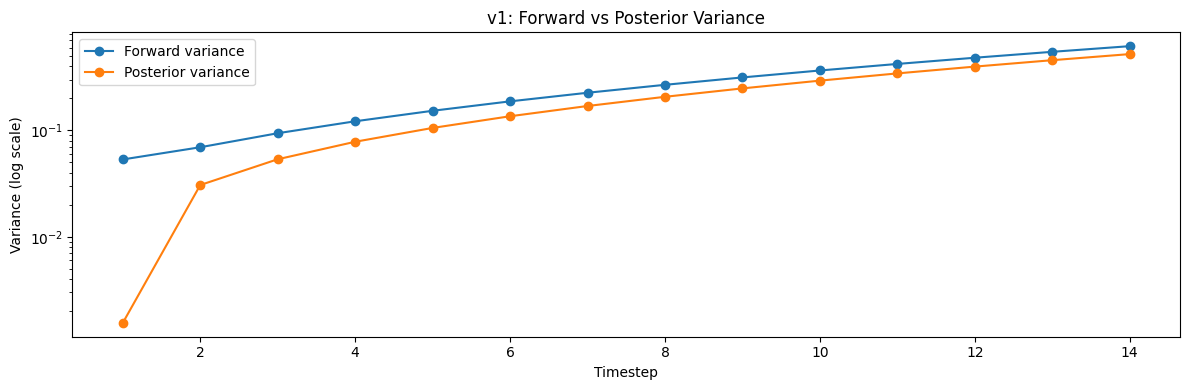

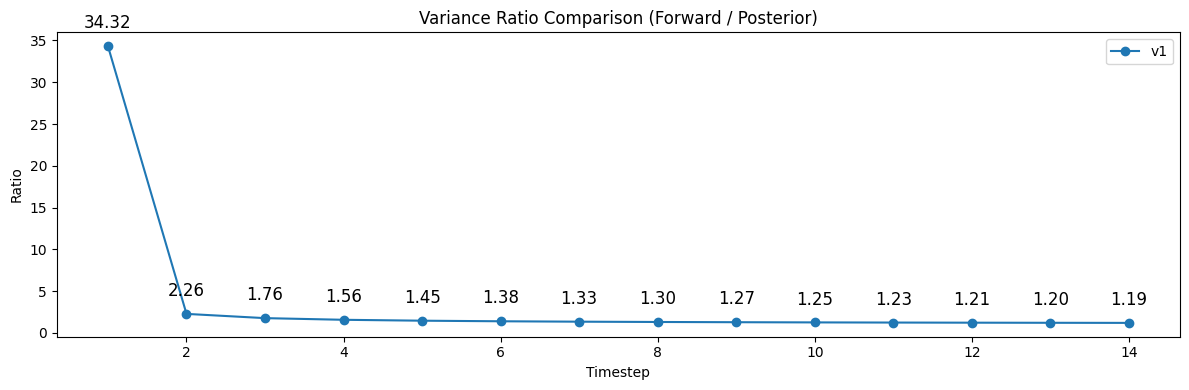

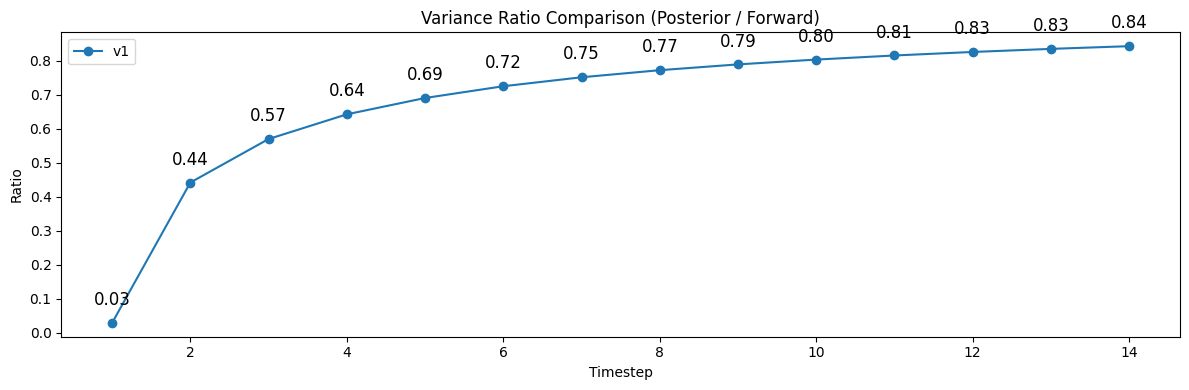

Summary:
v1: steps=15, F/P ratio range=(1.0300, 34.3191), P/F ratio range=(0.0291, 0.9709)


In [ ]:
results = {}
for name, cfg_path in MODEL_CONFIGS.items():
    diffusion = load_diffusion(cfg_path)
    results[name] = compute_variances(diffusion)

for name, data in results.items():
    timesteps, forward_var, posterior_var, _, _ = data
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    plot_variance_curves(ax, timesteps, forward_var, posterior_var, f'{name}: Forward vs Posterior Variance')
    plt.tight_layout()
    plt.show()

plot_ratio_overlay(results, ratio_type='forward_over_posterior')


plot_ratio_overlay(results, ratio_type='posterior_over_forward')

print('Summary:')
for name, data in results.items():
    timesteps, forward_var, posterior_var, ratio_f_p, ratio_p_f = data
    print(f'{name}: steps={len(timesteps)}, F/P ratio range=({ratio_f_p.min():.4f}, {ratio_f_p.max():.4f}), P/F ratio range=({ratio_p_f.min():.4f}, {ratio_p_f.max():.4f})')

# Save v1_diffusion for later use in multi-image analysis
v1_diffusion = load_diffusion(MODEL_CONFIGS["v1"])

## Multi-Image Averaged Variance Analysis

Process all LR images in IMAGE_DIR and compute averaged variance metrics

In [5]:
# ===== MULTI-IMAGE ANALYSIS: Process All LR Images =====

all_image_files = sorted(list(IMAGE_DIR.glob("*.png")))

num_timesteps = v1_diffusion.num_timesteps

# Initialize arrays to accumulate variances for all images
all_forward_vars_list = []
all_posterior_vars_list = []
all_ratios_f_p_list = []
all_ratios_p_f_list = []

# Process each image
for img_idx, img_file in enumerate(all_image_files, 1):
    try:
        timesteps = np.arange(num_timesteps)
        forward_var = v1_diffusion.alpha * (v1_diffusion.kappa ** 2)
        posterior_var = v1_diffusion.posterior_variance_clipped
        ratio_f_p = forward_var / posterior_var
        ratio_p_f = posterior_var / forward_var
        
        all_forward_vars_list.append(forward_var)
        all_posterior_vars_list.append(posterior_var)
        all_ratios_f_p_list.append(ratio_f_p)
        all_ratios_p_f_list.append(ratio_p_f)
    except Exception as e:
        print(f"  [{img_idx:2d}/{len(all_image_files)}] {img_file.name} - ERROR")

# Convert to arrays and compute means
all_forward_vars_arr = np.array(all_forward_vars_list)
all_posterior_vars_arr = np.array(all_posterior_vars_list)
all_ratios_f_p_arr = np.array(all_ratios_f_p_list)
all_ratios_p_f_arr = np.array(all_ratios_p_f_list)

# Compute averages across all images
mean_forward_var = all_forward_vars_arr.mean(axis=0)
mean_posterior_var = all_posterior_vars_arr.mean(axis=0)
mean_ratio_f_p = all_ratios_f_p_arr.mean(axis=0)
mean_ratio_p_f = all_ratios_p_f_arr.mean(axis=0)

# Compute standard deviations
std_forward_var = all_forward_vars_arr.std(axis=0)
std_posterior_var = all_posterior_vars_arr.std(axis=0)
std_ratio_f_p = all_ratios_f_p_arr.std(axis=0)
std_ratio_p_f = all_ratios_p_f_arr.std(axis=0)


multi_image_results = {
    "mean_forward_var": mean_forward_var,
    "mean_posterior_var": mean_posterior_var,
    "mean_ratio_f_p": mean_ratio_f_p,
    "mean_ratio_p_f": mean_ratio_p_f,
    "std_forward_var": std_forward_var,
    "std_posterior_var": std_posterior_var,
    "std_ratio_f_p": std_ratio_f_p,
    "std_ratio_p_f": std_ratio_p_f,
    "timesteps": timesteps
}

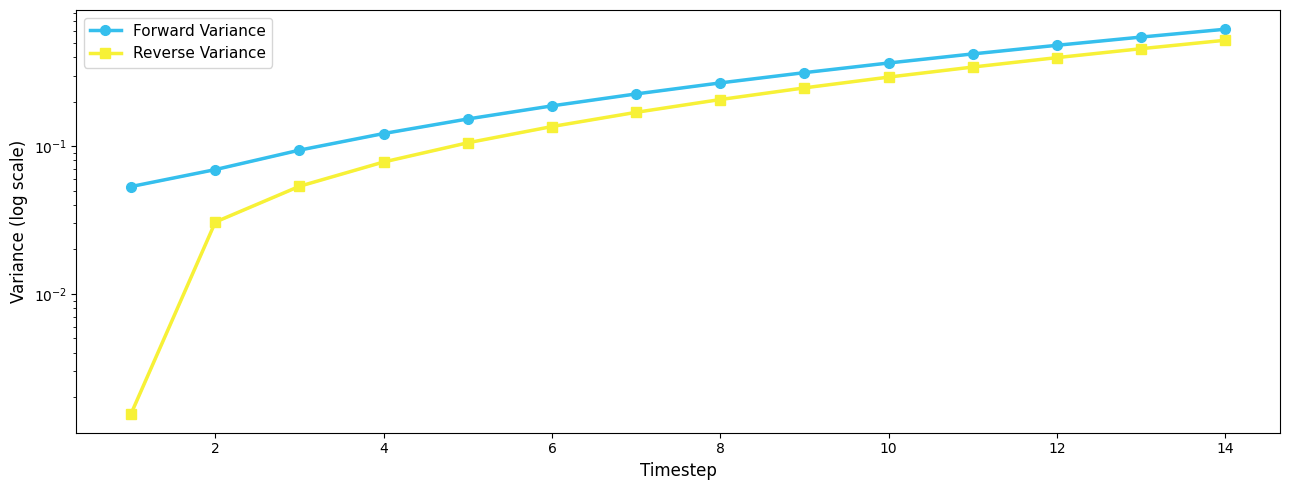

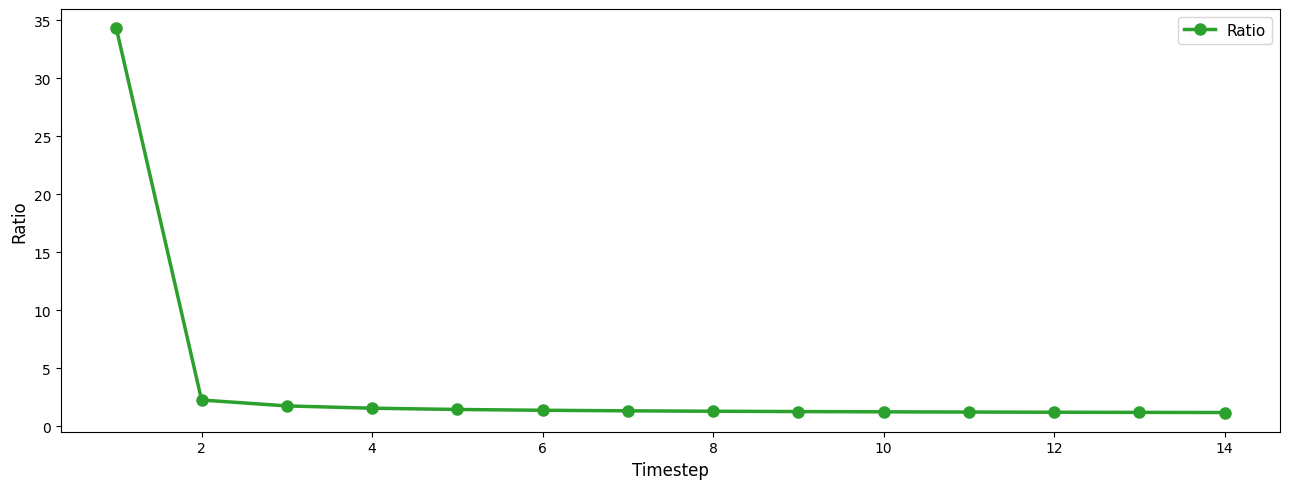

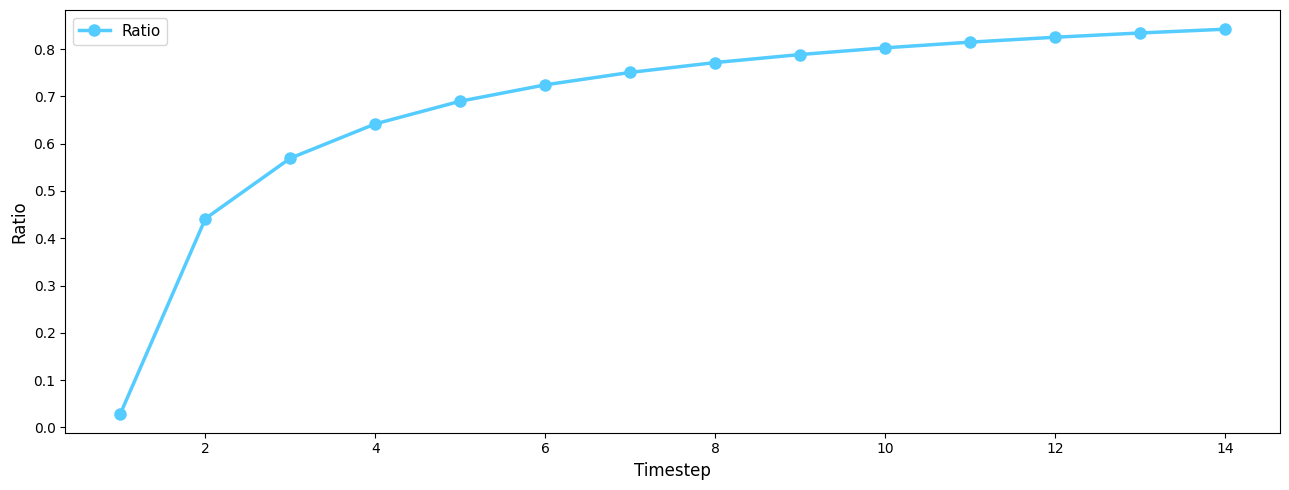

In [ ]:
# ===== VISUALIZATION: Multi-Image Averaged Results =====

# Get data from results
timesteps = multi_image_results["timesteps"]
mean_forward_var = multi_image_results["mean_forward_var"]
mean_posterior_var = multi_image_results["mean_posterior_var"]
mean_ratio_f_p = multi_image_results["mean_ratio_f_p"]
mean_ratio_p_f = multi_image_results["mean_ratio_p_f"]
std_forward_var = multi_image_results["std_forward_var"]
std_posterior_var = multi_image_results["std_posterior_var"]
std_ratio_f_p = multi_image_results["std_ratio_f_p"]
std_ratio_p_f = multi_image_results["std_ratio_p_f"]



timesteps = timesteps[1:]

mean_forward_var = mean_forward_var[1:]
mean_posterior_var = mean_posterior_var[1:]
mean_ratio_f_p = mean_ratio_f_p[1:]
mean_ratio_p_f = mean_ratio_p_f[1:]

std_forward_var = std_forward_var[1:]
std_posterior_var = std_posterior_var[1:]
std_ratio_f_p = std_ratio_f_p[1:]
std_ratio_p_f = std_ratio_p_f[1:]


# Create results directory if it doesn't exist
Path("./analysis_results").mkdir(exist_ok=True)

# Plot 1: Mean Forward vs Posterior Variance (with error bands)
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.plot(timesteps, mean_forward_var, marker='o', linewidth=2.5, markersize=7, 
        label='Forward Variance', color="#35bfed")
ax.fill_between(timesteps, mean_forward_var - std_forward_var, mean_forward_var + std_forward_var, 
                alpha=0.2, color='#35bfed')

ax.plot(timesteps, mean_posterior_var, marker='s', linewidth=2.5, markersize=7, 
        label='Reverse Variance', color="#f7f137")
ax.fill_between(timesteps, mean_posterior_var - std_posterior_var, mean_posterior_var + std_posterior_var, 
                alpha=0.2, color='#f7f137')

ax.set_yscale('log')
ax.set_title('', fontsize=13, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Variance (log scale)', fontsize=12)
ax.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.savefig('./analysis_results/mean_forward_vs_posterior_variance.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.plot(timesteps, mean_ratio_f_p, marker='o', linewidth=2.5, markersize=8, 
        label='Ratio', color='#2ca02c')



ax.set_title('', 
            fontsize=13, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Ratio', fontsize=12)

ax.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.savefig('./analysis_results/mean_variance_ratio_f_p.png', dpi=300, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.plot(timesteps, mean_ratio_p_f, marker='o', linewidth=2.5, markersize=8, 
        label='Ratio', color="#54ccff")

ax.set_title('', 
            fontsize=13, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Ratio', fontsize=12)

ax.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.savefig('./analysis_results/mean_variance_ratio_p_f.png', dpi=300, bbox_inches='tight')
plt.show()
